# **The 6-step Data Quality Method**
## https://github.com/royruddle/6-step-data-quality-method

This is the notebook that is used in the YouTube video about **Step 4** of the method (https://www.youtube.com/watch?v=QRo_kHNol6A), and shows how to use the vizdataquality package to investigate data quality.

The 6 steps are:
1. Is anything obviously wrong?
2. Watch out for special values
3. Is any data missing?
4. Check each variable
5. Check combinations of variables
6. Profile the cleaned data

## **Step 4: Check each variable (is it what you expect?)**

This step uses off-street parking fines data ('Quarter 4 201819.csv'; https://datamillnorth.org/dataset/v8ggw/off-street-parking-fines), (c) Leeds City Council, 2019. The data is licensed under the terms of the Open Government Licence (https://www.nationalarchives.gov.uk/doc/open-government-licence/version/2/).

Checks performed:
- Number of unique values: All 8 variables
- Frequency measures:
    - Value counts: PCN, FINE, CONTRAVENTION, LOCATION
    - Numerical distribution: Total Paid, Balance
    - Date distribtion: ISSUED, Last Pay Date
- Value lengths: All 8 variables
- Unusual category name: CONTRAVENTION, LOCATION

## Includes: viz_data_quality and other libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from vizdataquality import calculate as vdqc, plot as vdqp

## Read the datafile

In [2]:
folder = '../../examples'
input_filename = os.path.join(folder, 'Quarter 4 201819.csv')

# Read the dataset, but only treat empty cells as missing values
df = pd.read_csv(input_filename, encoding='ascii', na_values='', keep_default_na=False,
                 parse_dates=['ISSUED', 'Last Pay Date'], dayfirst=True, low_memory=False)
# Drop the extra, blank column that was found during Step 1
df = df.drop(df.columns[-1], axis='columns')

## Uniqueness

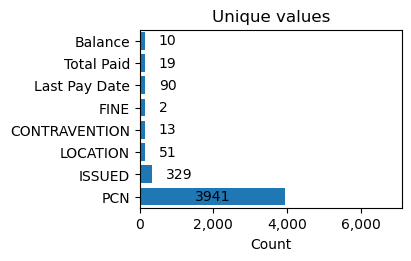

In [3]:
# Calculate statistics about each variable
column_stats = vdqc.calc(df)

fig_kw = {'size_inches': (4, 2.5), 'constrained_layout': True}
num_rows = len(df)
ax_kw = {'title': 'Unique values', 'xlim': (0, num_rows), 'xlabel': 'Count', 'ylabel': None}
vdqp.scalar_bar(column_stats['Number of unique values'], perceptual_threshold=0.02, vert=False, datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)

## PCN

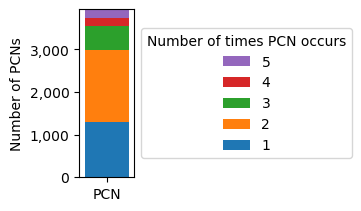

In [4]:
# Number of times each PCN occurs in the datafile
pcn_cnt = df['PCN'].value_counts()
# Number of PCNs that occur 1, 2, 3, etc. times
vc = pcn_cnt.value_counts().sort_index()

fig_kw = {'size_inches': (3.5, 2), 'constrained_layout': True}
vc.name = 'PCN'
ax_kw = {'xlabel': None, 'ylim': (0, vc.sum()), 'ylabel': 'Number of PCNs'}
legend_kw = {'title': 'Number of times PCN occurs', 'loc': 'center left', 'bbox_to_anchor': (1, 0.5), 'reverse': True}
vdqp.stacked_bar(vc, fig_kw=fig_kw, ax_kw=ax_kw, legend_kw=legend_kw)

## FINE

### Sum of the FINE column

In [5]:
print('Sum of the FINE column =', '£' + str(df['FINE'].sum()))

Sum of the FINE column = £362160


### But most PCNs occur in 2+ rows

In [6]:
# Check each PCN has a consistent FINE/ISSUED/CONTRAVENTION/LOCATION
columns = ['FINE', 'ISSUED', 'CONTRAVENTION', 'LOCATION']
df_noduplicates = df[['PCN'] + columns].drop_duplicates()
print('Number unique PCNs', df['PCN'].nunique())
print('Number of unique pairs for', columns, len(df_noduplicates))
print()
print('Total of fines issued =', '£' + str(df_noduplicates['FINE'].sum()))

Number unique PCNs 3941
Number of unique pairs for ['FINE', 'ISSUED', 'CONTRAVENTION', 'LOCATION'] 3941

Total of fines issued = £200650


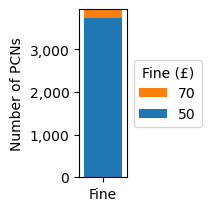

In [7]:
# Plot the number of fines of each value
vc_fine = df_noduplicates['FINE'].value_counts()
vc_fine.name = 'Fine'
fig_kw = {'size_inches': (2, 2), 'constrained_layout': True}
ax_kw = {'xlabel': None, 'ylim': (0, vc_fine.sum()), 'ylabel': 'Number of PCNs'}
legend_kw = {'title': 'Fine (£)', 'loc': 'center left', 'bbox_to_anchor': (1, 0.5), 'reverse': True}
vdqp.stacked_bar(vc_fine.sort_index(), fig_kw=fig_kw, ax_kw=ax_kw, legend_kw=legend_kw)

## Total Paid

### Sum of the Total Paid column

In [8]:
print('Sum of the Total Paid column =', '£' + str(df['Total Paid'].sum()))

Sum of the Total Paid column = £191106.02


### But what was the actual Total Paid?

In [9]:
columns = ['PCN', 'Total Paid']
df_max_paid = df[columns].sort_values(columns, ascending=False).drop_duplicates()
print('Total actually paid =', '£' + str(df_max_paid['Total Paid'].sum()))

Total actually paid = £106806.93


### Visualize Total Paid

#### Matplotlib histogram

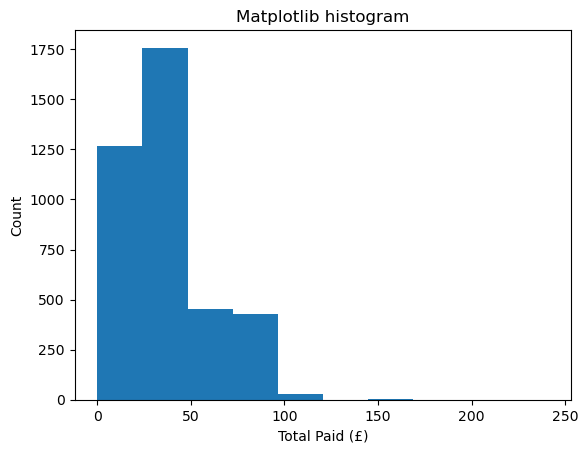

In [10]:
plt.hist(df_max_paid['Total Paid'])
plt.xlabel('Total Paid (£)')
plt.ylabel('Count')
plt.title('Matplotlib histogram')
plt.show()

#### vizdataquality histogram

By using perceptual discontinuity, we ensure all of the bars are visible

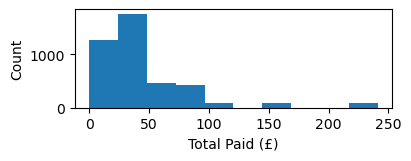

In [11]:
fig_kw = {'size_inches': (4, 1.5), 'constrained_layout': True}
ax_kw = {'xlabel': 'Total Paid (£)'}
vdqp.histogram(df_max_paid['Total Paid'], fig_kw=fig_kw, ax_kw=ax_kw)

#### Boxplot

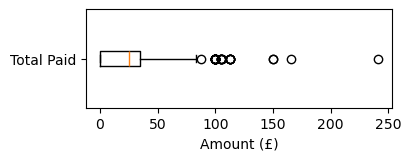

In [12]:
ax_kw = {'xlabel': 'Amount (£)', 'ylabel': None}
vdqp.boxplot_raw(df_max_paid['Total Paid'], vert=False, fig_kw=fig_kw, ax_kw=ax_kw)

#### Violin plot

Shows the true data distribution (multi-modal not unimodal)

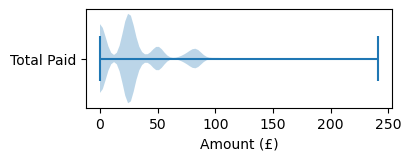

In [13]:
ax_kw = {'xlabel': 'Amount (£)', 'ylabel': None}
vdqp.violinplot(df_max_paid['Total Paid'], vert=False, fig_kw=fig_kw, ax_kw=ax_kw)

## Date ISSUED

RECAP: Step 1 "Example Values" showed that ISSUED and Last Pay Date do not contain time stamps

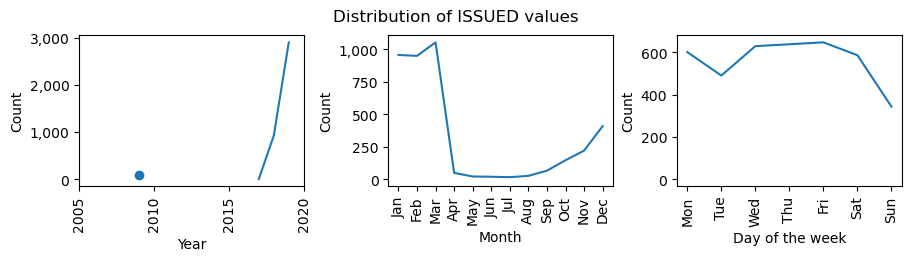

In [14]:
fig_kw = {'size_inches': (9, 2.5), 'constrained_layout': True}
ax_kw = {'title': 'Distribution of ISSUED values'}
components = ['year', 'month', 'dayofweek']
xrot = [90, 90, 90]
vdqp.plotgrid('datetime distribution', df_noduplicates['ISSUED'], num_rows=1, xlabels_rotate=xrot, fig_kw=fig_kw, ax_kw=ax_kw, components=components)

## Last Pay Date

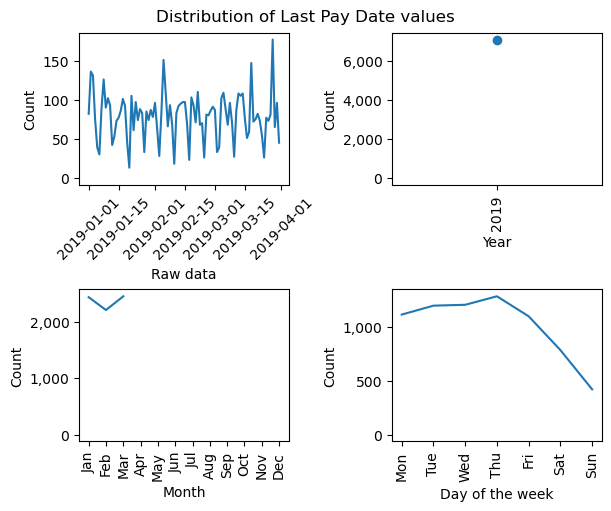

In [15]:
fig_kw = {'size_inches': (6, 5), 'constrained_layout': True}
ax_kw = {'title': 'Distribution of Last Pay Date values'}
components = ['raw data', 'year', 'month', 'dayofweek']
xrot = [45, 90, 90, 90]
vdqp.plotgrid('datetime distribution', df['Last Pay Date'], num_cols=2, xlabels_rotate=xrot, fig_kw=fig_kw, ax_kw=ax_kw, components=components)

## Value lengths

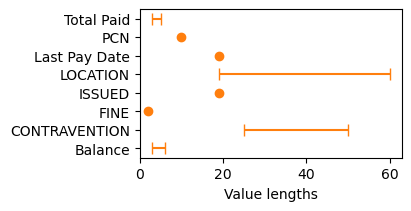

In [16]:
fig_kw = {'size_inches': (4, 2), 'constrained_layout': True}
ax_kw = {'xlim': 0, 'ylabel': None}
vdqp.dot_whisker(column_stats['Value lengths'].sort_index(), vert=False, fig_kw=fig_kw, ax_kw=ax_kw)

## Check for unusual category names

For any variables with a large range of value lengths, print the shortest, mid-length and longest value

In [17]:
columns = ['LOCATION', 'CONTRAVENTION']
df_examples = vdqc.get_value_lengths_examples(df[columns])

for col in df_examples.columns[1:]:
    print()
    print(col)
    for row in df_examples[['Examples', col]].itertuples(index=False):
        print(row[0].rjust(14) + ':', "'" + row[1] + "'")


LOCATION
Shortest value: 'CASTLE ST CP - CITY'
  Median value: 'AIREBOROUGH CENTRE - GUISELEY'
 Longest value: 'BURRAS LANE CP - OTLEY                                      '

CONTRAVENTION
Shortest value: '73 PARKED WITHOUT PAYMENT'
  Median value: '84 ADDITIONAL PAYMENT MADE TO EXTEND TIME'
 Longest value: '81 IN A RESTRICTED AREA IN A CAR PARK             '


## CONTRAVENTION

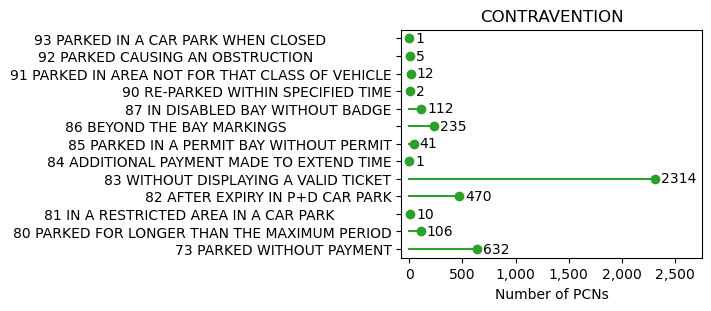

In [18]:
fig_kw = {'size_inches': (7, 3), 'constrained_layout': True}
ax_kw = {'title': 'CONTRAVENTION', 'xlabel': 'Number of PCNs', 'xlim': (-75, 2750), 'ylabel': None}
vdqp.lollipop(df_noduplicates['CONTRAVENTION'].value_counts(), vert=False, datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)

## LOCATION

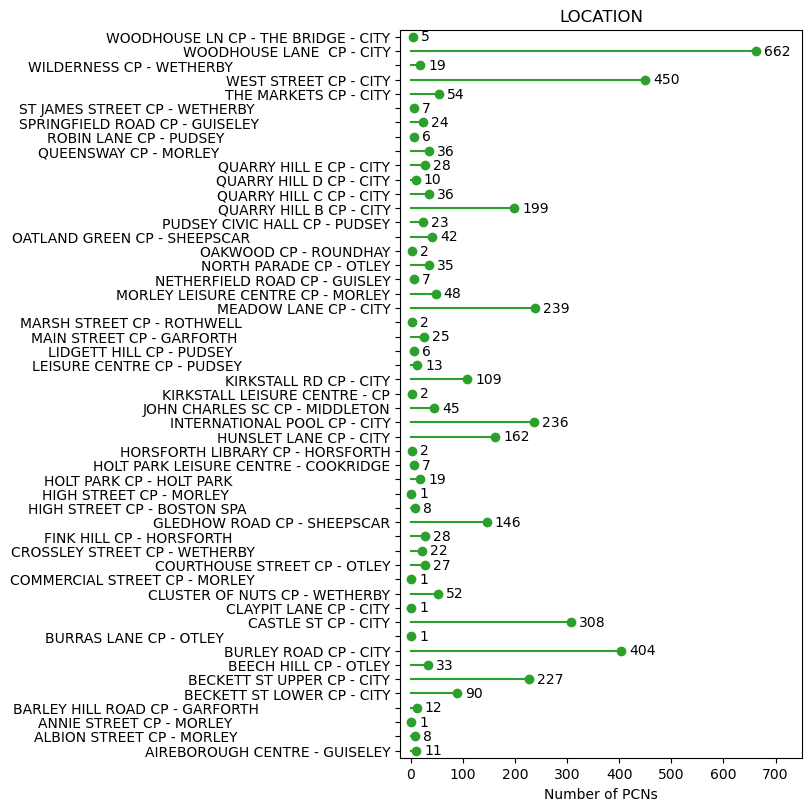

In [19]:
fig_kw = {'size_inches': (8, 8), 'constrained_layout': True}
ax_kw = {'title': 'LOCATION', 'xlabel': 'Number of PCNs', 'xlim': (-20, 750), 'ylabel': None}
vdqp.lollipop(df_noduplicates['LOCATION'].value_counts(), vert=False, datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)

## Clean the data

Strip leading/trailing spaces in LOCATION and CONTRAVENTION values

In [20]:
df['LOCATION'] = df['LOCATION'].apply(lambda x: x.strip())
df['CONTRAVENTION'] = df['CONTRAVENTION'].apply(lambda x: x.strip())